In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import numpy as np
import seaborn as sns
from scipy import stats

!pip install plotly

## Importation des données

In [166]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CSV_URL = (
    "https://raw.githubusercontent.com/OpenExoplanetCatalogue/"
    "oec_tables/master/comma_separated/open_exoplanet_catalogue.txt"
)

df = pd.read_csv(CSV_URL, comment='#')

# On renomme les colonnes pour la lisibilité
COLS = [
    "name", "binary_flag", "mass", "radius", "period", "semi_major_axis",
    "eccentricity", "periastron", "longitude", "ascending_node",
    "inclination", "surface_temp", "age", "discovery_method",
    "discovery_year", "last_updated", "ra_string", "dec_string",
    "distance_pc", "host_star_mass", "host_star_radius",
    "host_star_metallicity", "host_star_temp", "host_star_age",
    "list_flag"
]

print(f"Nombre de planètes chargées : {len(df)}")
print(f"\nColonnes disponibles :\n{df.dtypes}")

Nombre de planètes chargées : 5414

Colonnes disponibles :
name                      object
binaryflag                 int64
mass                     float64
radius                   float64
period                   float64
semimajoraxis            float64
eccentricity             float64
periastron               float64
longitude                float64
ascendingnode            float64
inclination              float64
temperature              float64
age                      float64
discoverymethod           object
discoveryyear            float64
lastupdate                object
system_rightascension     object
system_declination        object
system_distance          float64
hoststar_mass            float64
hoststar_radius          float64
hoststar_metallicity     float64
hoststar_temperature     float64
hoststar_age             float64
list                      object
dtype: object


# Acte III : Biais de détection

Dans l'Acte II, nous avons vu que les clusters C0 et C2 étaient dominés par le transit, tandis que C1 l'était par la vitesse radiale. Ce n'est pas une coïncidence. Ces deux méthodes ne détectent pas les mêmes types de planètes. Dans cet acte, nous allons explorer ces biais et comprendre comment ils façonnent notre vision du cosmos.

## Distribution des méthodes de détection

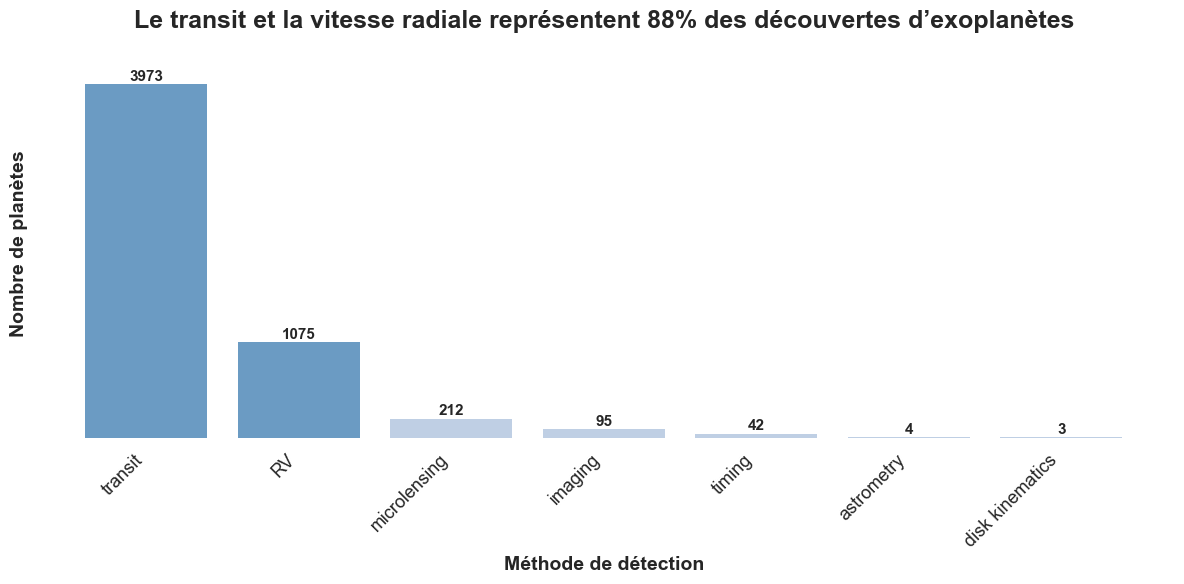

In [167]:
import matplotlib.pyplot as plt

method_counts = df['discoverymethod'].value_counts()

# Définition des couleurs
def get_color(method):
    method_lower = str(method).lower()
    if 'transit' in method_lower or 'rv' in method_lower or 'radial' in method_lower:
        return 'steelblue'
    return 'lightsteelblue'

colors = [get_color(m) for m in method_counts.index]

plt.figure(figsize=(12,6))

# Création du diagramme en barres sans bordures
bars = plt.bar(method_counts.index,
               method_counts.values,
               color=colors,
               edgecolor='none',
               alpha=0.8)

# Ajout des valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Méthode de détection', fontsize=14, fontweight='bold')
plt.ylabel('Nombre de planètes', fontsize=14, fontweight='bold')

plt.title('Le transit et la vitesse radiale représentent 88% des découvertes d’exoplanètes',
          fontsize=18, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=13)

plt.grid(False)

plt.yticks([])

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.ylim(0, max(method_counts.values) * 1.1)

plt.tight_layout()
plt.show()

Deux méthodes dominent très largement le recensement des exoplanètes. Le transit (Kepler) et la vitesse radiale représentent à elles seules près de 88 % des découvertes. L'imagerie directe, la microlentille et les autres méthodes restent plutôt marginales.

### Evolution temporelle des découvertes

In [168]:

# Définir une palette fixe et mappée aux méthodes de découverte
discovery_methods = ["transit", "rv", "imaging", "microlensing", "timing", "astrometry", "disk kinematics"]

# Palette de couleurs distincte et contrastée
color_palette = {
    "transit": "#1f77b4",           # Bleu
    "rv": "#ff7f0e",                # Orange
    "imaging": "#2ca02c",           # Vert
    "microlensing": "#d62728",      # Rouge
    "timing": "#9467bd",            # Violet
    "astrometry": "#8c564b",        # Marron
    "disk kinematics": "#e377c2"    # Rose
}

# Normaliser les noms de méthode pour éviter les problèmes de casse
def normalize_method(method):
    if pd.isna(method):
        return method
    method_lower = str(method).lower().strip()
    if method_lower in ["rv", "radial velocity"]:
        return "rv"
    return method_lower

/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_70536/916766344.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["discoverymethod_normalized"] = df_clean["discoverymethod"].apply(normalize_method)


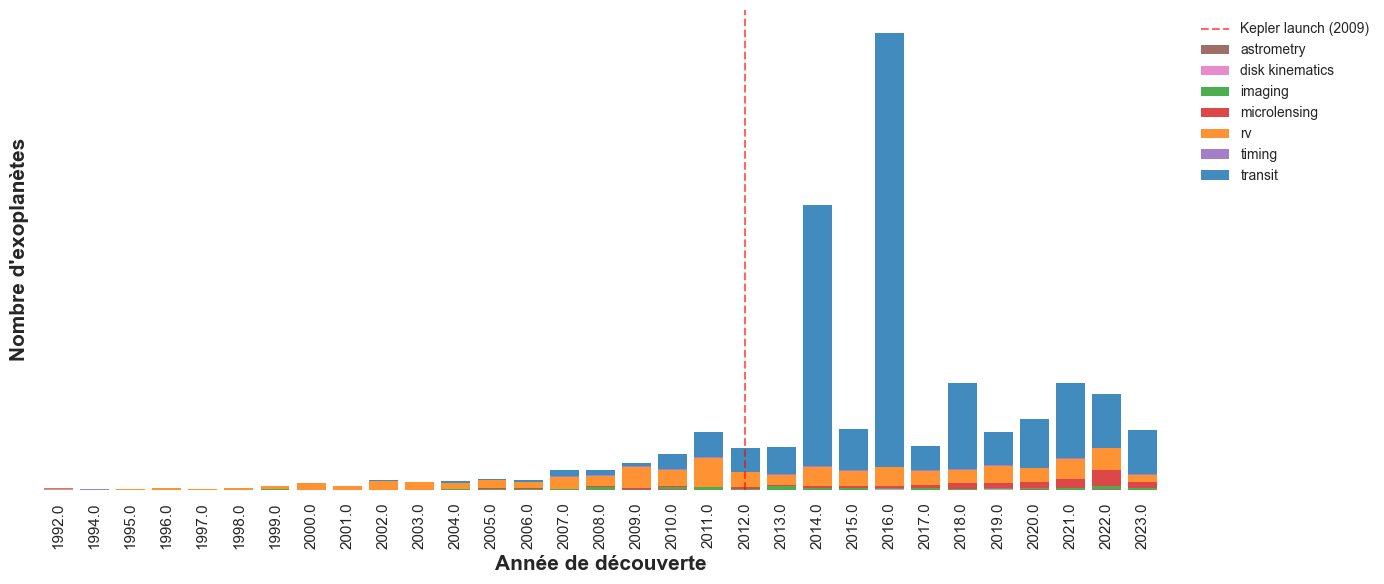

In [169]:
df_clean = df.dropna(subset=["discoverymethod"])
df_clean["discoverymethod_normalized"] = df_clean["discoverymethod"].apply(normalize_method)
 
discovery_counts = (
    df_clean
    .groupby(["discoveryyear", "discoverymethod_normalized"])
    .size()
    .reset_index(name="count")
    .pivot(index="discoveryyear", columns="discoverymethod_normalized", values="count")
    .fillna(0)
)
 
# Réordonner les colonnes selon la palette
discovery_counts = discovery_counts[[col for col in discovery_counts.columns if col in color_palette]]
 
fig, ax = plt.subplots(figsize=(14, 6))
 
discovery_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.8,
    edgecolor='none',
    alpha=0.85,
    color=[color_palette.get(col, '#cccccc') for col in discovery_counts.columns]
)
 
# Ajoute une ligne verticale pour marquer le début de Kepler
plt.axvline(x=19, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Kepler launch (2009)')
 
plt.xlabel("Année de découverte", fontsize=15, fontweight='bold')
plt.ylabel("Nombre d'exoplanètes", fontsize=15, fontweight='bold')
 
plt.ylim(bottom=0)
plt.grid(False)
plt.yticks([])
 
# Supprime tous les cadres
for spine in ax.spines.values():
    spine.set_visible(False)
 
plt.legend(loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('viz1_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()

L'évolution temporelle raconte une histoire. Avant 2009, la vitesse radiale régnait en maître. Mais le lancement de Kepler a tout changé. À partir de 2010, les transits explosent et deviennent la méthode dominante. Aujourd'hui, la majorité des exoplanètes connues viennent de Kepler et de sa successeuse TESS.

## Distribution des masses par méthode (boxplot)

/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_70536/4128328417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_box["discoverymethod_normalized"] = df_box["discoverymethod"].apply(normalize_method)
/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_70536/4128328417.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


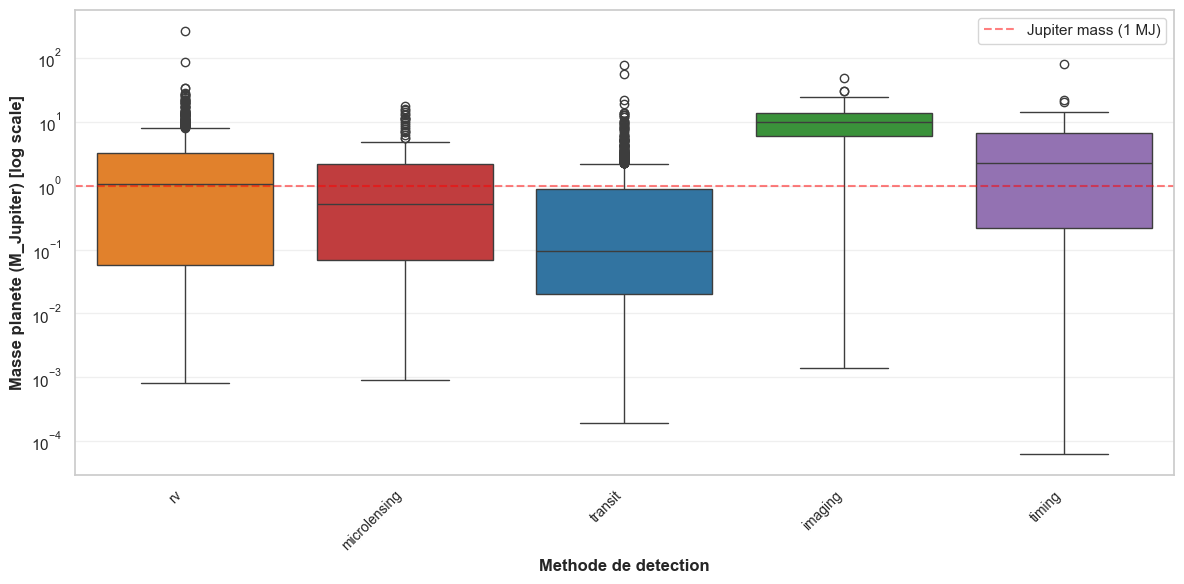

In [158]:
df_box = df.dropna(subset=['mass', 'discoverymethod'])
df_box["discoverymethod_normalized"] = df_box["discoverymethod"].apply(normalize_method)
 
# Garder les méthodes avec au moins 10 planètes
top_methods = df_box['discoverymethod_normalized'].value_counts()[df_box['discoverymethod_normalized'].value_counts() >= 10].index
df_box_filtered = df_box[df_box['discoverymethod_normalized'].isin(top_methods)]
 
fig, ax = plt.subplots(figsize=(12, 6))
 
# Créer la palette pour les méthodes présentes
box_palette = {method: color_palette.get(method, '#cccccc') for method in top_methods}
 
sns.boxplot(
    data=df_box_filtered,
    x='discoverymethod_normalized',
    y='mass',
    palette=box_palette,
    ax=ax
)
 
plt.yscale('log')
plt.xlabel('Methode de detection', fontsize=12, fontweight='bold')
plt.ylabel('Masse planete (M_Jupiter) [log scale]', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
 
# Ajouter une ligne de référence pour Jupiter (1 MJ)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Jupiter mass (1 MJ)')
plt.legend()
 
plt.tight_layout()
plt.savefig('viz2_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
 

Les différences entre méthodes sont nettes. Le transit détecte surtout des planètes de faible masse, tandis que la vitesse radiale couvre une gamme plus large et plus massive. L’imagerie est fortement biaisée vers des planètes très massives. Chaque méthode a ainsi sa "zone de confort", révélant des populations différentes et introduisant des biais d’observation.

In [101]:
print(df.columns.tolist())

['name', 'binaryflag', 'mass', 'radius', 'period', 'semimajoraxis', 'eccentricity', 'periastron', 'longitude', 'ascendingnode', 'inclination', 'temperature', 'age', 'discoverymethod', 'discoveryyear', 'lastupdate', 'system_rightascension', 'system_declination', 'system_distance', 'hoststar_mass', 'hoststar_radius', 'hoststar_metallicity', 'hoststar_temperature', 'hoststar_age', 'list']


## Retour sur la loi de Kepler

/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_70536/794520761.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scatter["discoverymethod_normalized"] = df_scatter["discoverymethod"].apply(normalize_method)


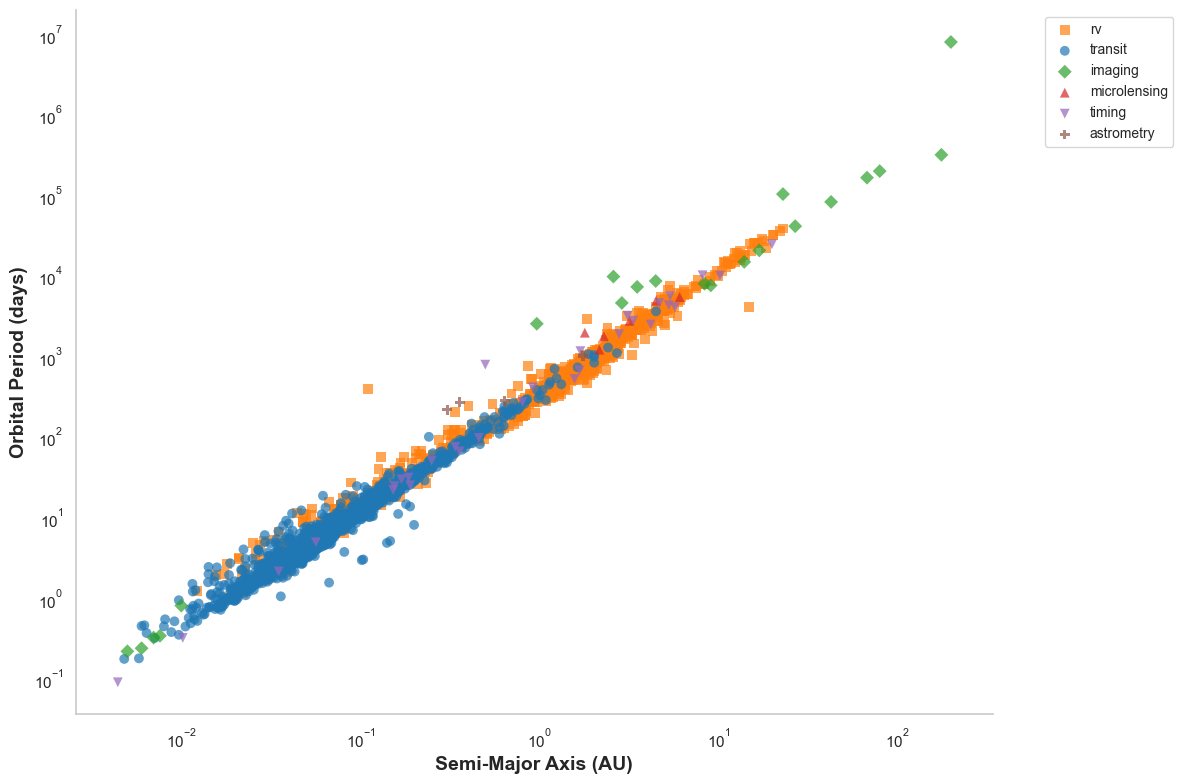

In [159]:
df_scatter = df.dropna(subset=['semimajoraxis', 'period', 'discoverymethod'])
df_scatter["discoverymethod_normalized"] = df_scatter["discoverymethod"].apply(normalize_method)
 
# Mapping formes (markers)
markers = {
    "transit": "o",
    "rv": "s",
    "imaging": "D",
    "microlensing": "^",
    "timing": "v",
    "astrometry": "P",
    "disk kinematics": "*",
}
 
fig, ax = plt.subplots(figsize=(12, 8))
 
# Pour chaque méthode, tracer avec sa couleur et sa forme
for method in df_scatter["discoverymethod_normalized"].unique():
    if pd.isna(method):
        continue
    
    data_subset = df_scatter[df_scatter["discoverymethod_normalized"] == method]
    
    ax.scatter(
        data_subset["semimajoraxis"],
        data_subset["period"],
        color=color_palette.get(method, '#cccccc'),
        marker=markers.get(method, 'o'),
        label=method,
        alpha=0.7,
        s=50,
        edgecolors='none'
    )
 
plt.xscale("log")
plt.yscale("log")
 
plt.xlabel("Semi-Major Axis (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Orbital Period (days)", fontsize=14, fontweight='bold')

 
plt.grid(False)
 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
 
ax.tick_params(axis='both', which='major', labelsize=11)
 
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.savefig('viz3_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Les planètes que nous détectons en majorité sont celles qui ont des périodes courtes (transit) ou des masses élevées (RV). Si nous pouvions observer toutes les planètes, verrions-nous encore cette relation ? Peut-être que notre échantillon est biaisé par les limites instrumentales.

## Hot Jupiters

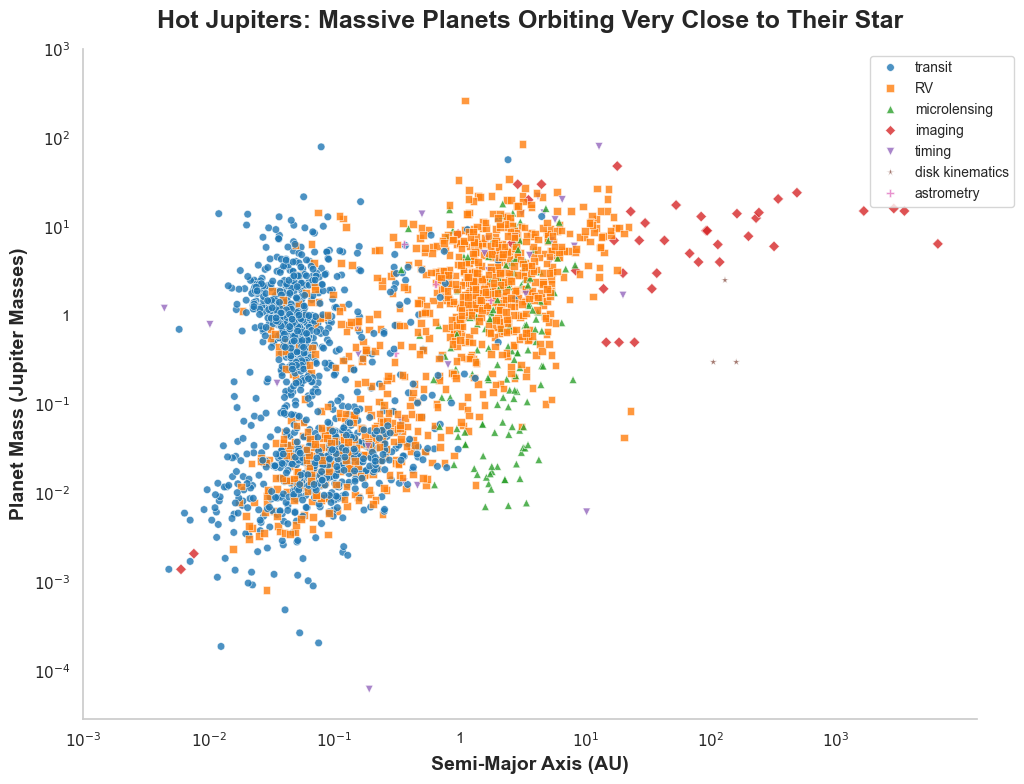

In [164]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="semimajoraxis",
    y="mass",
    hue="discoverymethod",
    style="discoverymethod",
    markers=markers,
    palette=palette,
    alpha=0.8,
    s=30
)

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_xticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

ax.set_yticks([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels([r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

plt.xlabel("Semi-Major Axis (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Planet Mass (Jupiter Masses)", fontsize=14, fontweight='bold')
plt.title("Hot Jupiters: Massive Planets Orbiting Very Close to Their Star",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()

Souvenez-vous des Hot Jupiters vus dans l'Acte I. Pourquoi en avons-nous détecté autant ? Parce qu'ils sont idéaux pour le transit. Une grosse planète qui passe devant une petite étoile, ça produit un signal énorme. Ce n'est pas forcément qu'ils sont fréquents. C'est surtout qu'ils sont faciles à voir. C'est l'exemple parfait d'un biais de détection.

Ces biais nous rappellent que notre carte des exoplanètes est encore partielle. Pour prendre conscience de l'étendue de ce qu'il nous reste à découvrir, plongeons maintenant dans une visualisation immersive de la Voie lactée.

## Des géantes si proches ? L'énigme des Hot Jupiters

Parmi toutes les exoplanètes, une famille se distingue : les Hot Jupiters. Ces géantes gazeuses orbitent à moins de 0,1 UA de leur étoile, c'est à dire, vingt fois plus près que la Terre du Soleil. Leurs masses provoquent d'importantes perturbations de leur étoile hote (plus gros effet Doppler).Leur existence défie certaines théories de formation planétaire et illustre la diversité extrême des systèmes exoplanétaires.

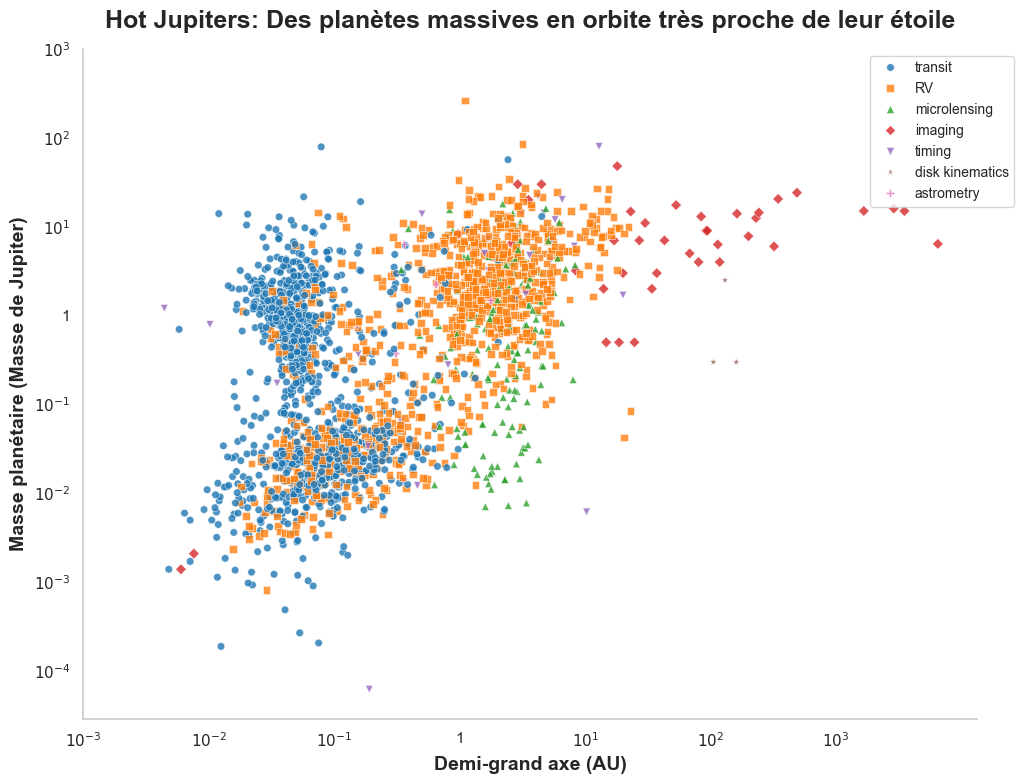

In [163]:
plt.figure(figsize=(12,8))

markers = {
    "transit": "o",
    "rv": "s",
    "RV": "s",
    "disk kinematics": "*",
    "radial velocity": "s",
    "imaging": "D",
    "microlensing": "^",
    "timing": "v",
    "astrometry": "P"
}

# Palette de couleurs
methods = df['discoverymethod'].unique()
palette = dict(zip(methods, sns.color_palette("tab10", n_colors=len(methods))))

sns.scatterplot(
    data=df,
    x="semimajoraxis",
    y="mass",
    hue="discoverymethod",
    style="discoverymethod",
    markers=markers,
    palette=palette,
    alpha=0.8,
    s=30
)

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_xticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

ax.set_yticks([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels([r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

plt.xlabel("Demi-grand axe (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Masse planétaire (Masse de Jupiter)", fontsize=14, fontweight='bold')
plt.title("Hot Jupiters: Des planètes massives en orbite très proche de leur étoile",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()